In [4]:
import glob
import re
import os
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
from scipy.interpolate import interp1d

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 150
plt.rcParams.update({"font.size": 10})

# -------------------------------
# Directory containing the files
# -------------------------------
in_dir = "../out"
out_dir = "../out"
os.makedirs(out_dir, exist_ok=True)

# -------------------------------
# Find and group files
# -------------------------------
files = glob.glob(os.path.join(in_dir, "*.out"))
pattern = re.compile(r"^(.*?)_mpi\d+_(.*?)\.out$")  # capture <something> and <something_else>

groups = defaultdict(list)
for f in files:
    fname = os.path.basename(f)
    m = pattern.match(fname)
    if m:
        key = (m.group(1), m.group(2))
        groups[key].append(f)

# -------------------------------
# Combine each group
# -------------------------------
for (prefix, suffix), flist in groups.items():
    flist = sorted(flist)
    out_file = os.path.join(out_dir, f"{prefix}_mpi_{suffix}.out")
    with open(out_file, "w") as fout:
        for fname in flist:
            with open(fname) as fin:
                for line in fin:
                    fout.write(line)
    print(f"Combined {len(flist)} files into {out_file}")


Combined 2 files into ../out/nfw_mpi_fmm_2.out
Combined 2 files into ../out/nfw_mpi_fmm_1.out


In [5]:
def load_data(filename1, filename2, out_dir="../out"):
    names = ["x", "y", "z", "fx", "fy", "fz", "phi"]
    file1 = os.path.join(out_dir, filename1)
    file2 = os.path.join(out_dir, filename2)

    df1 = pd.read_csv(file1, header=None, sep=r"\s+", names=names)
    df2 = pd.read_csv(file2, header=None, sep=r"\s+", names=names)

    for df in [df1, df2]:
        df["x"] -= df["x"].min()
        df["y"] -= df["y"].min()
        df["z"] -= df["z"].min()

    return df1, df2, filename1, filename2

# ---------------------------------------------------------------------
# 2D comparison plot
# ---------------------------------------------------------------------
def plot_2d(df1, df2, label1, label2, z_slice):
    df1_slice = df1[np.isclose(df1["z"], z_slice)]
    df2_slice = df2[np.isclose(df2["z"], z_slice)]

    grid1 = df1_slice.pivot(index="y", columns="x", values="phi")
    grid2 = df2_slice.pivot(index="y", columns="x", values="phi")

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    im0 = axs[0].imshow(grid1.values, origin="lower", cmap="viridis")
    axs[0].set_title(f"{label1}  (z={z_slice})")
    plt.colorbar(im0, ax=axs[0])

    im1 = axs[1].imshow(grid2.values, origin="lower", cmap="viridis")
    axs[1].set_title(f"{label2}  (z={z_slice})")
    plt.colorbar(im1, ax=axs[1])

    diff = grid2.values - grid1.values
    with np.errstate(divide="ignore", invalid="ignore"):
        rel_diff = np.where(grid1.values != 0, diff / grid1.values, 0)
    im2 = axs[2].imshow(rel_diff, origin="lower", cmap="coolwarm")
    axs[2].set_title("Relative Difference")
    plt.colorbar(im2, ax=axs[2])

    plt.tight_layout()
    os.makedirs("./fig", exist_ok=True)
    plt.savefig(f"./fig/compare_2d_{z_slice}_{label1}_vs_{label2}.png", dpi=200)
    plt.show()

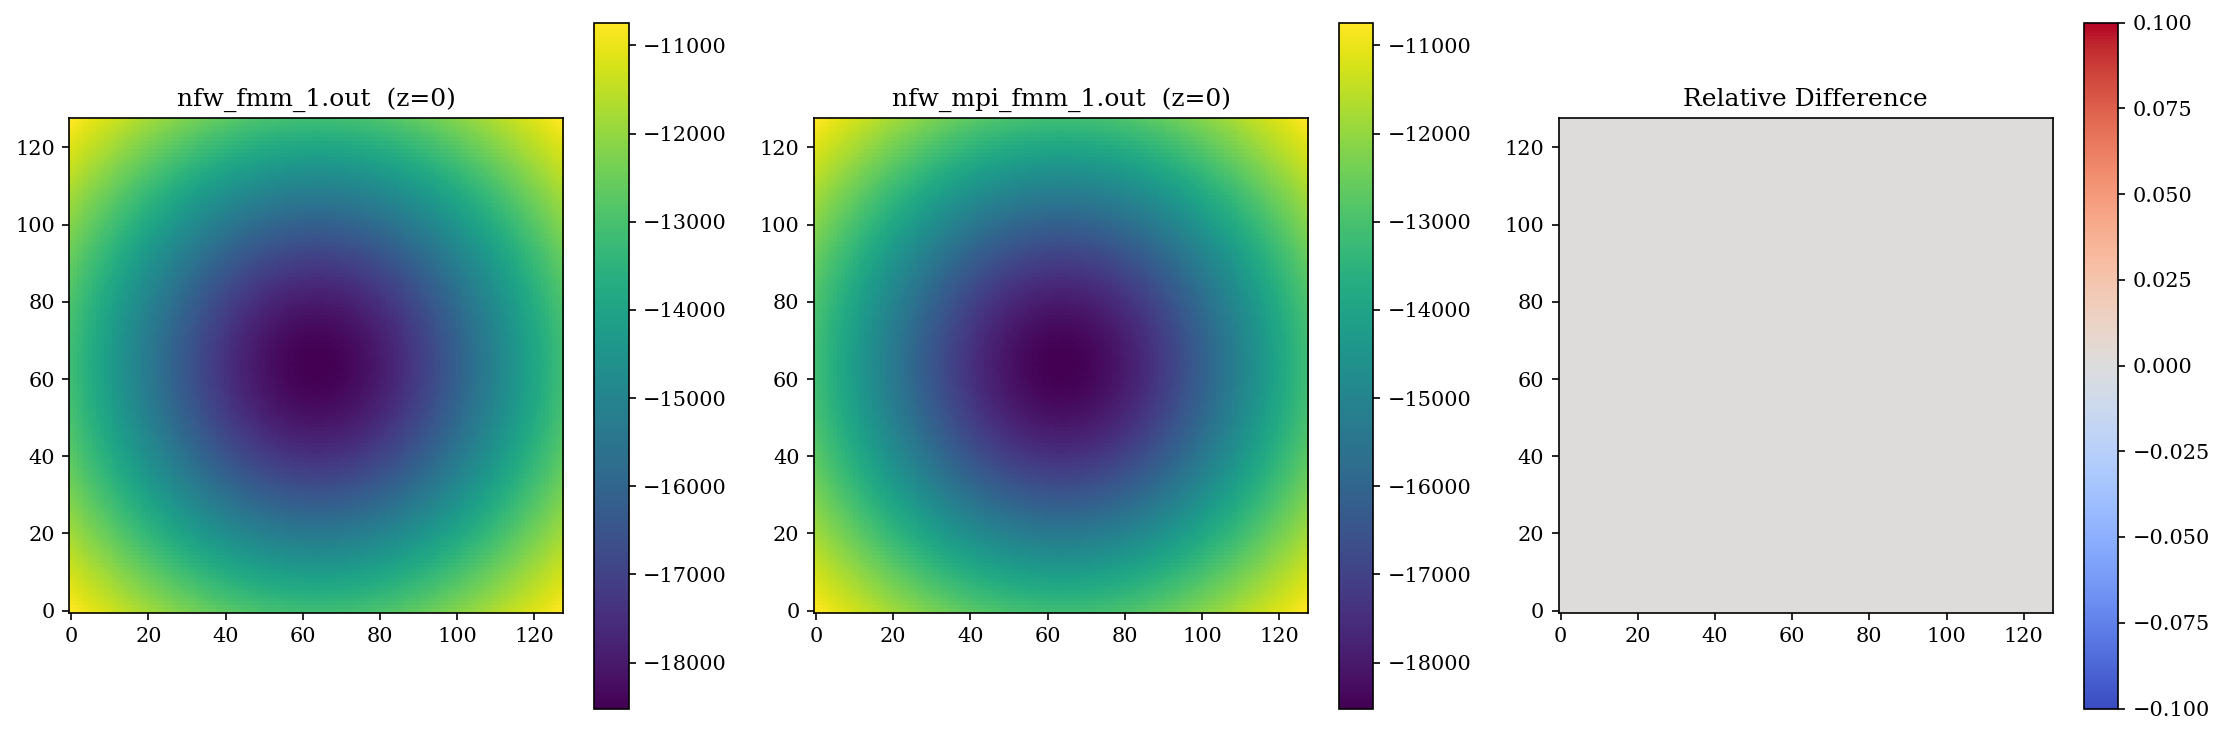

In [6]:
file1 = "nfw_fmm_1.out"
file2 = "nfw_mpi_fmm_1.out"  # if filename contains "nfw", overlay NFW analytic
z_slice = 0

df1, df2, label1, label2 = load_data(file1, file2)
plot_2d(df1, df2, label1, label2, z_slice)